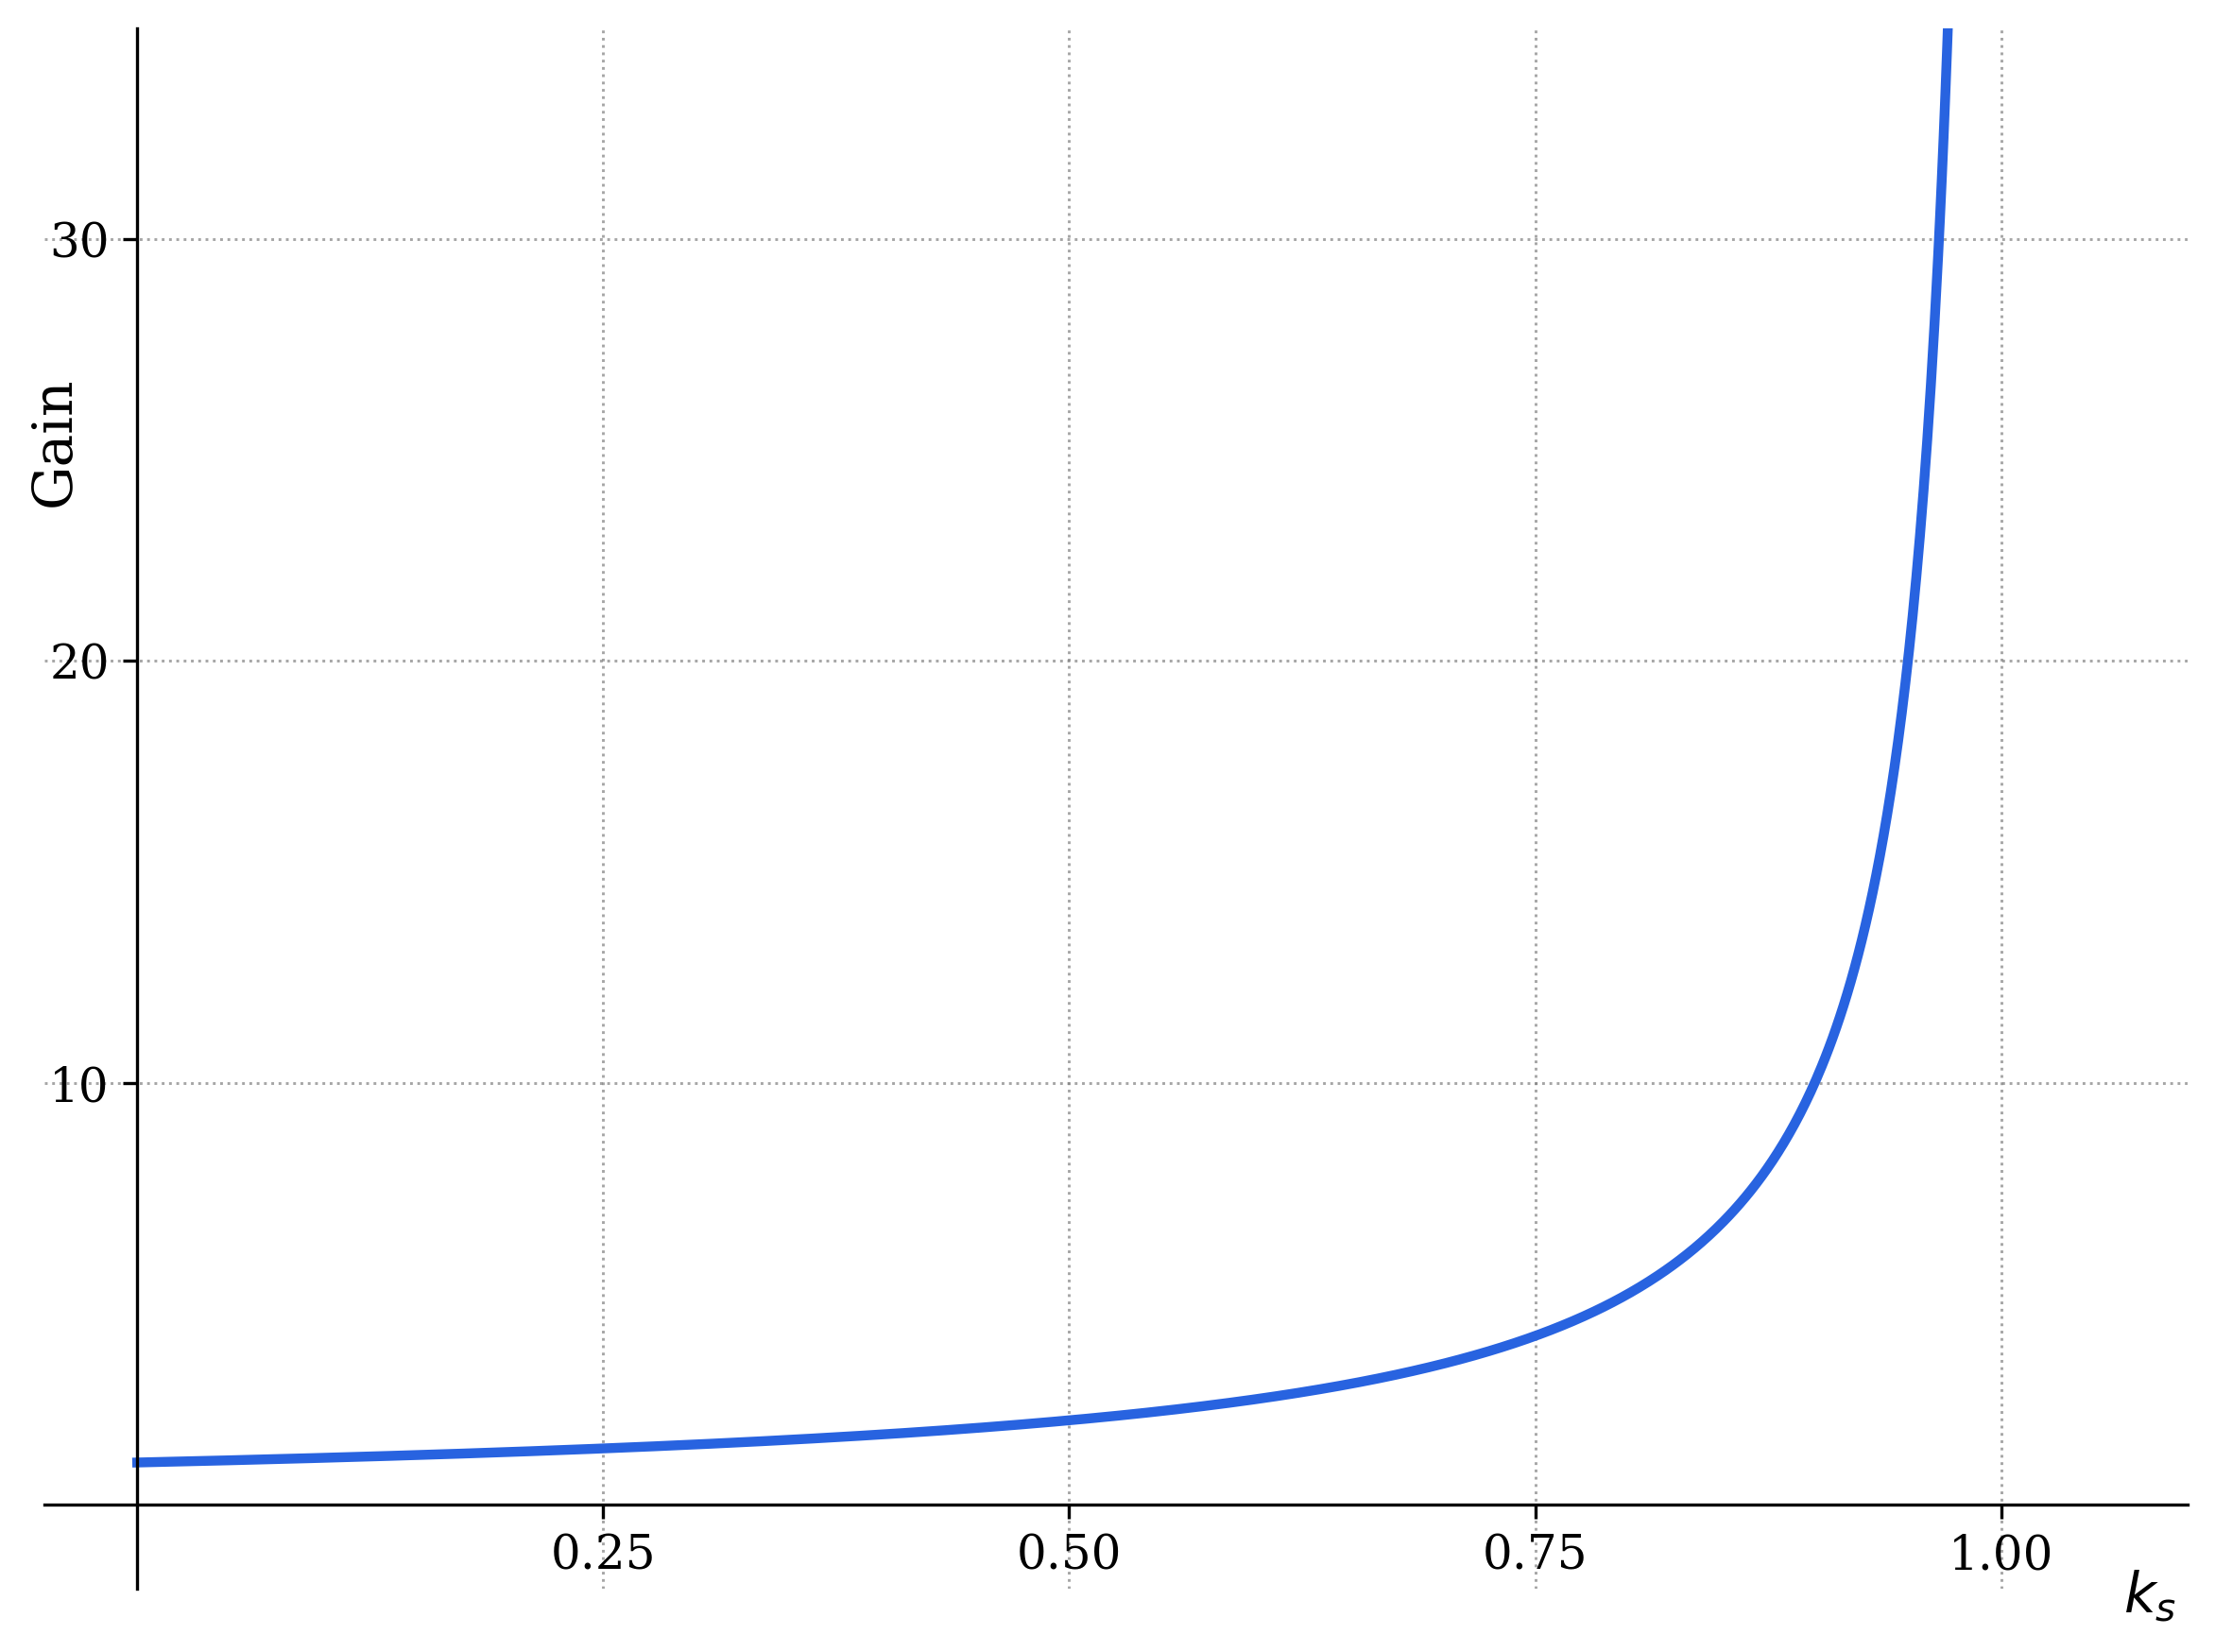

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Configurazione dello stile per renderlo formale e adatto a una tesi
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# Generazione dei dati: asintoto per k_s -> 1
# Ci fermiamo un po' prima di 1 per evitare la divisione per zero e il picco all'infinito
ks = np.linspace(0, 0.975, 1000)
M = 1 / (1 - ks)

# Creazione della figura ad alta risoluzione (300 dpi)
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Plot della curva (colore rosso scuro/bordeaux, più elegante)
ax.plot(ks, M, color="#2863e0", linewidth=2.5)

# Personalizzazione degli assi (stile matematico passante per l'origine)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')  # Nasconde il bordo destro
ax.spines['top'].set_color('none')    # Nasconde il bordo superiore

# Impostazione dei limiti per centrare bene la curva
ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-2, 35)

# Configurazione dei Ticks (i numeri sugli assi)
ax.set_xticks([0.25, 0.5, 0.75 , 1.0])
ax.set_yticks([10, 20, 30])

# Riposizionamento manuale delle etichette degli assi per evitare sovrapposizioni
# con i numeri quando gli assi passano per l'origine
ax.text(1.08, -1.5, '$k_s$', fontsize=14, ha='center', va='top')
ax.text(-0.03, 25.2, 'Gain', fontsize=14, ha='right', va='center', rotation=90)

# Aggiunta di una griglia leggera
ax.grid(color='gray', linestyle=':', linewidth=0.7, alpha=0.7)

# Ottimizzazione degli spazi
plt.tight_layout()

# Decommenta la riga seguente per salvare l'immagine direttamente nella cartella del file python
# plt.savefig("grafico_moltiplicazione.png", format='png', dpi=300, bbox_inches='tight')

# Mostra il grafico
plt.show()

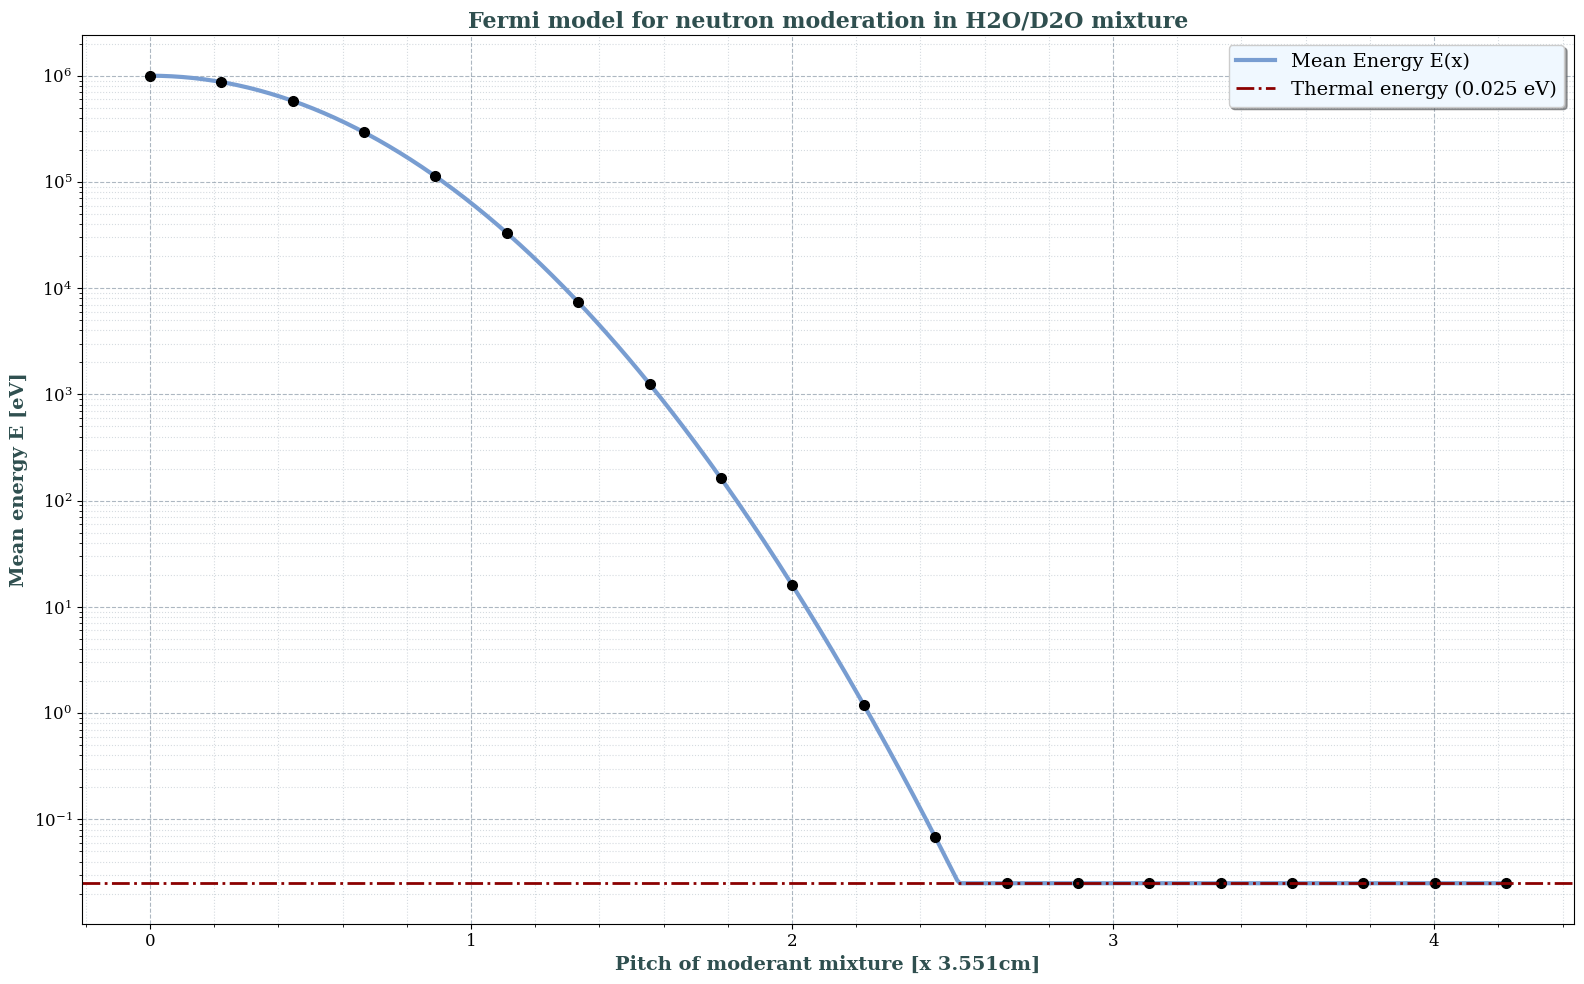

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PARAMETRI FISICI ---
E_0 = 1e6           # Energia iniziale [eV]
E_th = 0.025        # Energia termica [eV]
tau_th = 40.0       # Età di Fermi alla termalizzazione per la miscela H2O/D2O [cm^2]

# Calcolo del coefficiente di proporzionalità tau_0 = tau / u
u_th = np.log(E_0 / E_th)
tau_0 = tau_th / u_th

# Array dello spessore (da 0 a 15 cm)
x = np.linspace(0, 15, 500)

# Modello dell'energia in funzione dello spessore E(x)
E = E_0 * np.exp(-(x**2) / (2 * tau_0))

# Limite termico (il neutrone non scende sotto E_th)
E = np.maximum(E, E_th)

# --- 2. PLOTTING ---
fig, ax = plt.subplots(figsize=(16, 10))

# Curva continua
ax.plot(x/3.5507, E, color='#789DD1', linewidth=3, label='Mean Energy E(x)')

# Punti di campionamento spaziale
x_points = np.linspace(0, 15, 20)
E_points = E_0 * np.exp(-(x_points**2) / (2 * tau_0))
E_points = np.maximum(E_points, E_th)
ax.plot(x_points/3.5507, E_points, 'o', color='#000000', markersize=7)

# Linea asintoto termico
ax.axhline(E_th, color='#8B0000', linestyle='-.', linewidth=2, label='Thermal energy (0.025 eV)')

# Impostazione scala logaritmica
ax.set_yscale('log')

# --- 3. FORMATTAZIONE GRAFICA ---
ax.set_title("Fermi model for neutron moderation in H2O/D2O mixture", 
             fontsize=16, fontweight='bold', color='#2F4F4F')
ax.set_xlabel("Pitch of moderant mixture [x 3.551cm]", 
              fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("Mean energy E [eV]", 
              fontsize=14, fontweight='bold', color='#2F4F4F')

# Griglie e Tick
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')

# Limiti assi
#ax.set_xlim(0, 15.1)
#ax.set_ylim(1e-3, 2e6)

plt.tight_layout()
plt.savefig("decadimento_energia_moderazione.png", format='png', dpi=300, bbox_inches='tight')
plt.show()

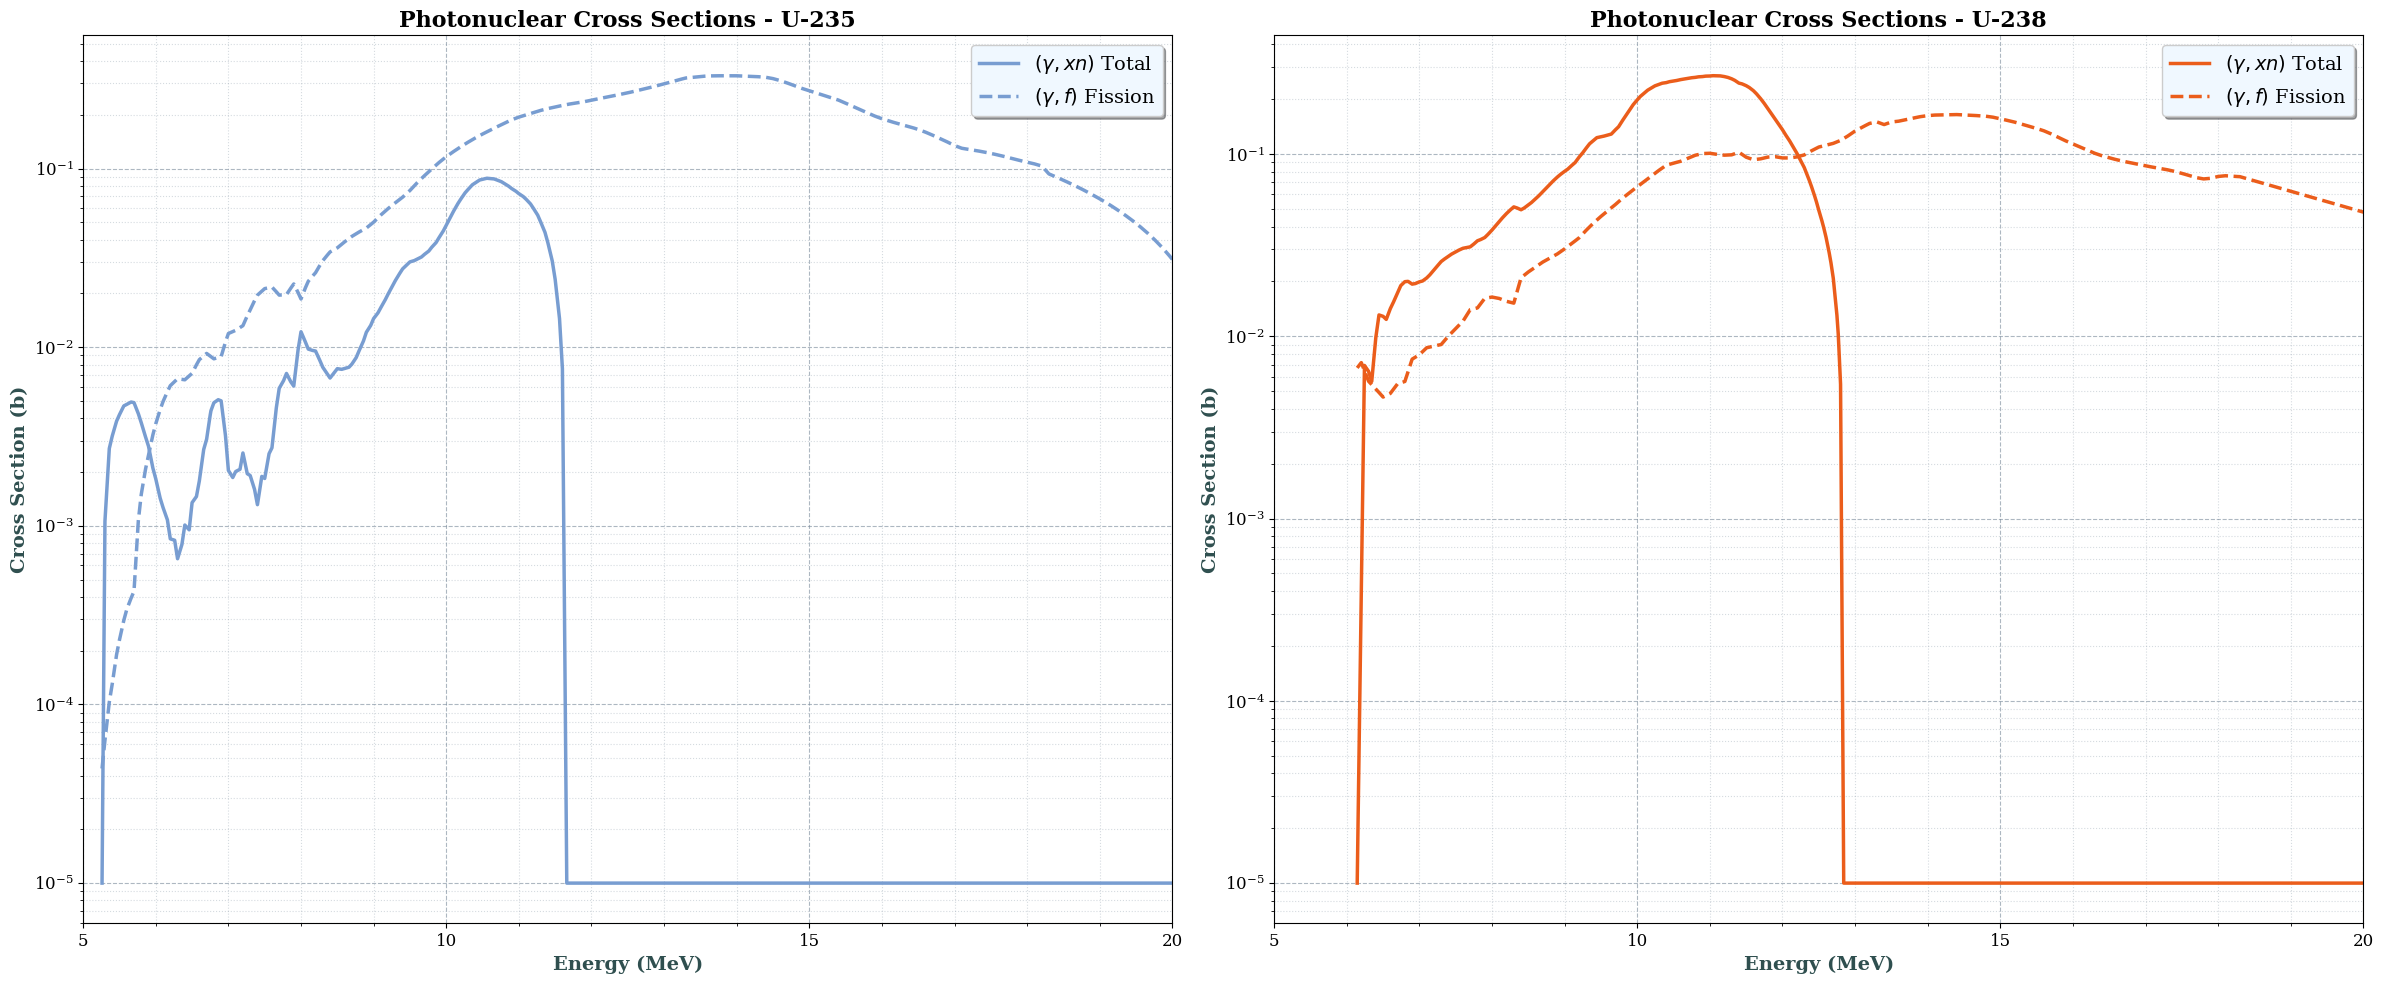

In [7]:
import openmc.data
import matplotlib.pyplot as plt
import numpy as np

# Caricamento dati
u235 = openmc.data.IncidentPhotonuclear.from_hdf5('/home/bossi_ricky/openmc_data/mcnp_endfb71/photonuclear/U235.h5')
u238 = openmc.data.IncidentPhotonuclear.from_hdf5('/home/bossi_ricky/openmc_data/mcnp_endfb71/photonuclear/U238.h5')

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

for ax, iso_data, title, base_color in zip(axes, [u235, u238], ['U-235', 'U-238'], ['#789DD1', "#EB5D1B"]):
    # Estrazione della sezione d'urto Totale (MT=5) per usarla come griglia energetica base
    if 5 not in iso_data.reactions:
        continue
    rx_tot = iso_data.reactions[5]
    energies_ev = rx_tot.xs.x
    energies_mev = energies_ev / 1e6
    
    # Focus sulla zona della GDR (5 - 20 MeV)
    mask = (energies_mev >= 5) & (energies_mev <= 20)
    e_plot = energies_mev[mask]
    
    xs_tot = rx_tot.xs(energies_ev[mask])
    
    # Estrazione della Fissione (MT=18)
    if 18 in iso_data.reactions:
        xs_fiss = iso_data.reactions[18].xs(energies_ev[mask])
    else:
        xs_fiss = np.zeros_like(e_plot)
    
    # Calcolo della (gamma, xn) totale per differenza
    xs_gn_tot = np.clip(xs_tot - xs_fiss, 1e-5, None)
    
    # Plot in semilogy (X lineare centra meglio la GDR)
    ax.semilogy(e_plot, xs_gn_tot, label=r'$(\gamma, xn)$ Total', 
                color=base_color, linestyle='-', linewidth=2.5)
    
    ax.semilogy(e_plot, xs_fiss, label=r'$(\gamma, f)$ Fission', 
                color=base_color, linestyle='--', linewidth=2.5)
    
    # Formattazione titolo e label
    ax.set_title(f"Photonuclear Cross Sections - {title}", fontsize=16, fontweight='bold')
    ax.set_xlabel('Energy (MeV)', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel("Cross Section (b)", fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # Formattazione rigorosa Asse X
    ax.set_xlim(5, 20)
    ax.set_xticks([5, 10, 15, 20])
    ax.set_xticklabels(['5', '10', '15', '20'])
    
    # Formattazione griglia e legenda
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.legend(loc='best', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')

plt.tight_layout()
plt.savefig('photonuclear_cross_sections.png', dpi=300, bbox_inches='tight')
plt.show()

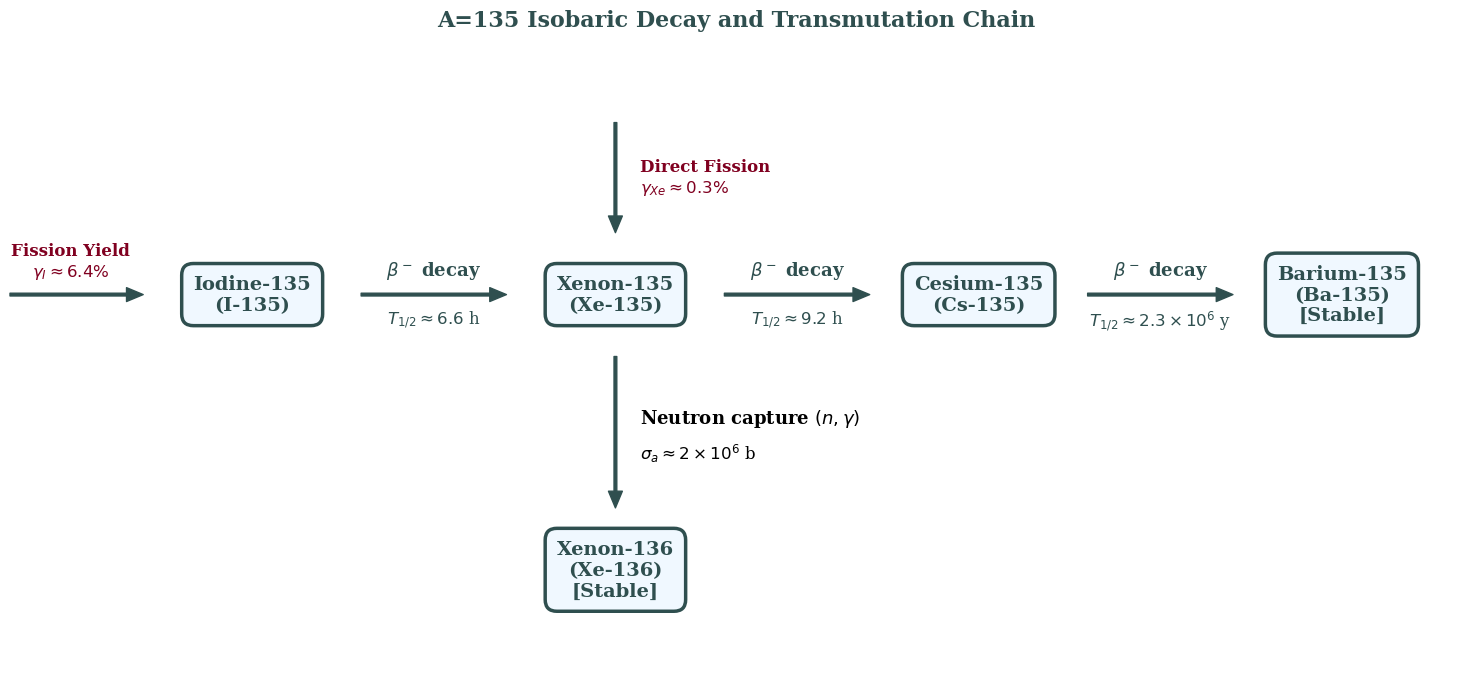

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 7))
ax.axis('off')

# Stili per i riquadri
bbox_props = dict(boxstyle="round,pad=0.6", fc="#F0F8FF", ec="#2F4F4F", lw=2.5)
arrow_props = dict(facecolor='#2F4F4F', edgecolor='#2F4F4F', width=2, headwidth=10, headlength=12, shrink=0.0)

# Creazione dei nodi
ax.text(0.15, 0.6, "Iodine-135\n(I-135)", ha="center", va="center", size=14, fontweight="bold", color="#2F4F4F", bbox=bbox_props)
ax.text(0.45, 0.6, "Xenon-135\n(Xe-135)", ha="center", va="center", size=14, fontweight="bold", color="#2F4F4F", bbox=bbox_props)
ax.text(0.75, 0.6, "Cesium-135\n(Cs-135)", ha="center", va="center", size=14, fontweight="bold", color="#2F4F4F", bbox=bbox_props)
ax.text(1.05, 0.6, "Barium-135\n(Ba-135)\n[Stable]", ha="center", va="center", size=14, fontweight="bold", color="#2F4F4F", bbox=bbox_props)
ax.text(0.45, 0.2, "Xenon-136\n(Xe-136)\n[Stable]", ha="center", va="center", size=14, fontweight="bold", color="#2F4F4F", bbox=bbox_props)

# 1. Fission -> I-135
ax.annotate("", xy=(0.06, 0.6), xytext=(-0.05, 0.6), arrowprops=arrow_props)
ax.text(0.0, 0.62, "Fission Yield\n$\gamma_I \\approx 6.4\\%$", ha="center", va="bottom", size=12, color="#800020", fontweight="bold")

# 2. I-135 -> Xe-135
ax.annotate("", xy=(0.36, 0.6), xytext=(0.24, 0.6), arrowprops=arrow_props)
ax.text(0.3, 0.62, r"$\beta^-$ decay", ha="center", va="bottom", size=13, fontweight="bold", color="#2F4F4F")
ax.text(0.3, 0.58, r"$T_{1/2} \approx 6.6$ h", ha="center", va="top", size=12, color="#2F4F4F")

# 3. Xe-135 -> Cs-135
ax.annotate("", xy=(0.66, 0.6), xytext=(0.54, 0.6), arrowprops=arrow_props)
ax.text(0.6, 0.62, r"$\beta^-$ decay", ha="center", va="bottom", size=13, fontweight="bold", color="#2F4F4F")
ax.text(0.6, 0.58, r"$T_{1/2} \approx 9.2$ h", ha="center", va="top", size=12, color="#2F4F4F")

# 4. Cs-135 -> Ba-135
ax.annotate("", xy=(0.96, 0.6), xytext=(0.84, 0.6), arrowprops=arrow_props)
ax.text(0.9, 0.62, r"$\beta^-$ decay", ha="center", va="bottom", size=13, fontweight="bold", color="#2F4F4F")
ax.text(0.9, 0.58, r"$T_{1/2} \approx 2.3 \times 10^6$ y", ha="center", va="top", size=12, color="#2F4F4F")

# 5. Fission -> Xe-135
ax.annotate("", xy=(0.45, 0.69), xytext=(0.45, 0.85), arrowprops=arrow_props)
ax.text(0.47, 0.77, "Direct Fission\n$\gamma_{Xe} \\approx 0.3\\%$", ha="left", va="center", size=12, color="#800020", fontweight="bold")

# 6. Xe-135 -> Xe-136 
ax.annotate("", xy=(0.45, 0.29), xytext=(0.45, 0.51), arrowprops=arrow_props)
ax.text(0.47, 0.42, "Neutron capture $(n,\gamma)$", ha="left", va="center", size=13, fontweight="bold", color="#000000")
ax.text(0.47, 0.37, r"$\sigma_{a} \approx 2 \times 10^6$ b", ha="left", va="center", size=12, color="#000000")

plt.title("A=135 Isobaric Decay and Transmutation Chain", fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
ax.set_xlim(-0.05, 1.15)
ax.set_ylim(0.05, 0.95)

plt.tight_layout()
plt.savefig('catena_decadimento_xenon_completa.png', dpi=300, bbox_inches='tight')
plt.show()

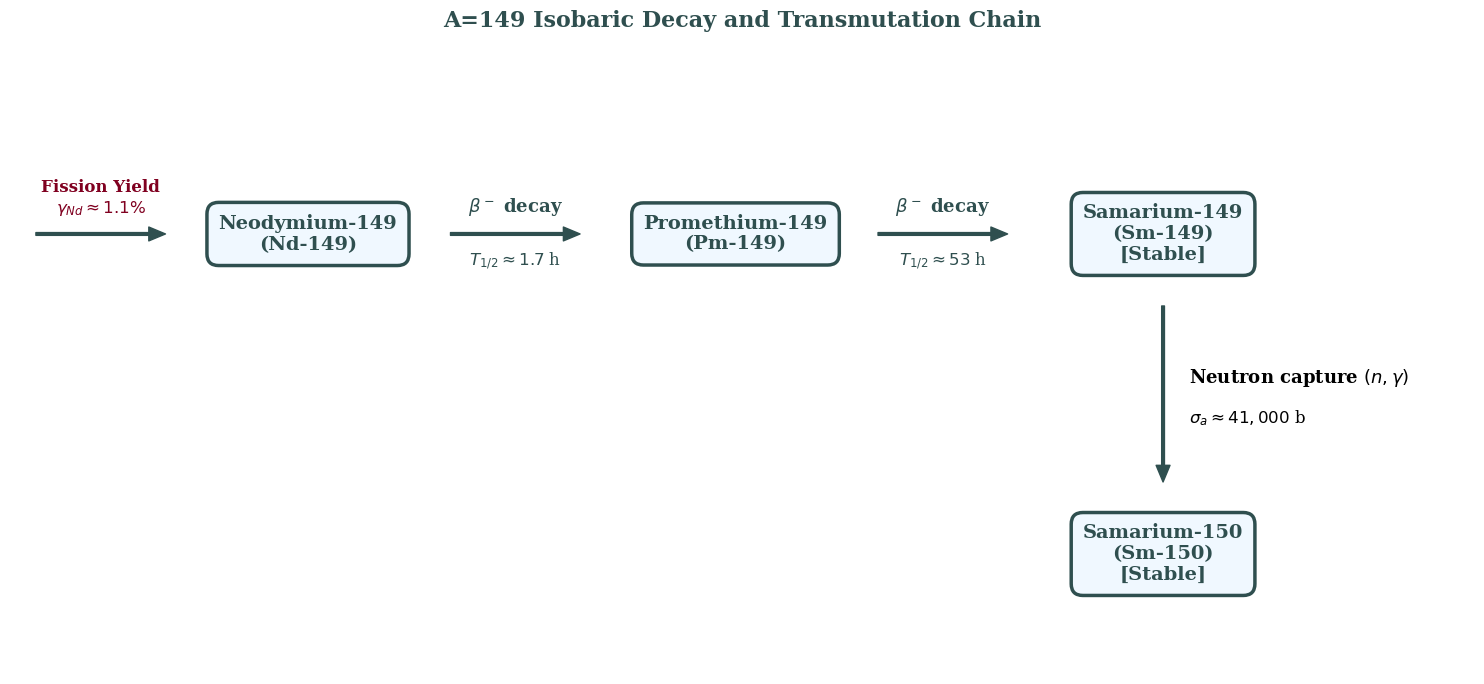

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 7))
ax.axis('off')

# Stili per i riquadri 
bbox_props = dict(boxstyle="round,pad=0.6", fc="#F0F8FF", ec="#2F4F4F", lw=2.5)
arrow_props = dict(facecolor='#2F4F4F', edgecolor='#2F4F4F', width=2, headwidth=10, headlength=12, shrink=0.0)

# Creazione dei nodi
ax.text(0.15, 0.6, "Neodymium-149\n(Nd-149)", ha="center", va="center", size=14, fontweight="bold", color="#2F4F4F", bbox=bbox_props)
ax.text(0.48, 0.6, "Promethium-149\n(Pm-149)", ha="center", va="center", size=14, fontweight="bold", color="#2F4F4F", bbox=bbox_props)
ax.text(0.81, 0.6, "Samarium-149\n(Sm-149)\n[Stable]", ha="center", va="center", size=14, fontweight="bold", color="#2F4F4F", bbox=bbox_props)
ax.text(0.81, 0.2, "Samarium-150\n(Sm-150)\n[Stable]", ha="center", va="center", size=14, fontweight="bold", color="#2F4F4F", bbox=bbox_props)

# 1. Produzione: Fission -> Nd-149
ax.annotate("", xy=(0.04, 0.6), xytext=(-0.06, 0.6), arrowprops=arrow_props)
ax.text(-0.01, 0.62, "Fission Yield\n$\gamma_{Nd} \\approx 1.1\\%$", ha="center", va="bottom", size=12, color="#800020", fontweight="bold")

# 2. Decadimento: Nd-149 -> Pm-149
ax.annotate("", xy=(0.36, 0.6), xytext=(0.26, 0.6), arrowprops=arrow_props)
ax.text(0.31, 0.62, r"$\beta^-$ decay", ha="center", va="bottom", size=13, fontweight="bold", color="#2F4F4F")
ax.text(0.31, 0.58, r"$T_{1/2} \approx 1.7$ h", ha="center", va="top", size=12, color="#2F4F4F")

# 3. Decadimento: Pm-149 -> Sm-149
ax.annotate("", xy=(0.69, 0.6), xytext=(0.59, 0.6), arrowprops=arrow_props)
ax.text(0.64, 0.62, r"$\beta^-$ decay", ha="center", va="bottom", size=13, fontweight="bold", color="#2F4F4F")
ax.text(0.64, 0.58, r"$T_{1/2} \approx 53$ h", ha="center", va="top", size=12, color="#2F4F4F")

# 4. Distruzione: Sm-149 -> Sm-150 (Neutron Capture)
ax.annotate("", xy=(0.81, 0.29), xytext=(0.81, 0.51), arrowprops=arrow_props)
ax.text(0.83, 0.42, "Neutron capture $(n,\gamma)$", ha="left", va="center", size=13, fontweight="bold", color="#000000")
ax.text(0.83, 0.37, r"$\sigma_{a} \approx 41,000$ b", ha="left", va="center", size=12, color="#000000")

# Titolo del Grafico (pad ridotto per avvicinarlo al grafico)
plt.title("A=149 Isobaric Decay and Transmutation Chain", fontsize=16, fontweight='bold', color='#2F4F4F', pad=5)

# Regolazione dei margini (limite y superiore ridotto per tagliare lo spazio vuoto)
ax.set_xlim(-0.08, 1.05)
ax.set_ylim(0.05, 0.85)

# Salvataggio ed esportazione
plt.tight_layout()
plt.savefig('catena_decadimento_samario.png', dpi=300, bbox_inches='tight')
plt.show()

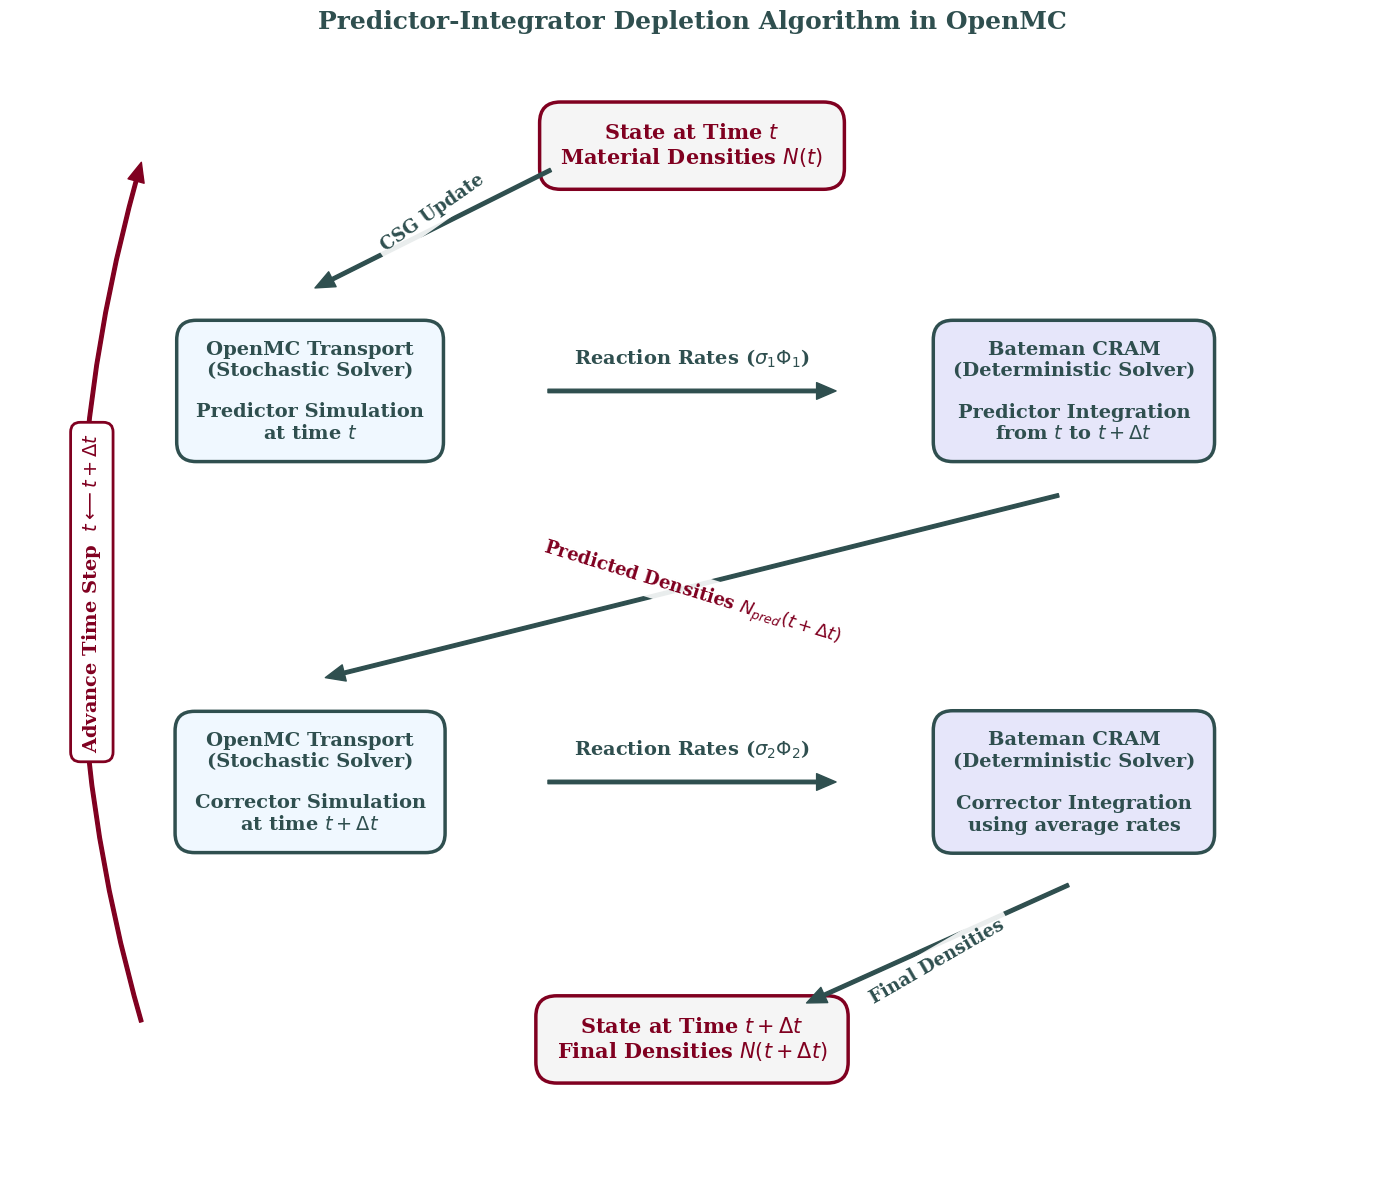

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 12))
ax.axis('off')

# Definizione dei colori (coerenti con la palette della tesi)
color_stoch = "#F0F8FF"
color_det = "#E6E6FA"
color_state = "#F5F5F5"
color_text = "#2F4F4F"
color_accent = "#800020"

# Proprietà dei riquadri
box_stoch = dict(boxstyle="round,pad=1.0", fc=color_stoch, ec=color_text, lw=2.5)
box_det = dict(boxstyle="round,pad=1.0", fc=color_det, ec=color_text, lw=2.5)
box_state = dict(boxstyle="round,pad=1.0", fc=color_state, ec=color_accent, lw=2.5)
box_white = dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9)

# Proprietà delle frecce
arrow_props = dict(facecolor=color_text, edgecolor=color_text, width=2.5, headwidth=12, headlength=14, shrink=0.02)
arrow_loop = dict(facecolor=color_accent, edgecolor=color_accent, width=2.5, headwidth=12, headlength=14, shrink=0.02, connectionstyle="arc3,rad=-0.15")

# --- DISEGNO DEI NODI (BLOCCHI LOGICI) ---

# 1. BOC
ax.text(0.5, 0.92, r"State at Time $t$" + "\n" + r"Material Densities $N(t)$", ha="center", va="center", size=15, fontweight="bold", color=color_accent, bbox=box_state)

# 2. OpenMC Predictor
ax.text(0.22, 0.70, "OpenMC Transport\n(Stochastic Solver)\n\n" + r"Predictor Simulation" + "\n" + r"at time $t$", ha="center", va="center", size=14, fontweight="bold", color=color_text, bbox=box_stoch)

# 3. CRAM Predictor
ax.text(0.78, 0.70, "Bateman CRAM\n(Deterministic Solver)\n\n" + r"Predictor Integration" + "\n" + r"from $t$ to $t+\Delta t$", ha="center", va="center", size=14, fontweight="bold", color=color_text, bbox=box_det)

# 4. OpenMC Corrector
ax.text(0.22, 0.35, "OpenMC Transport\n(Stochastic Solver)\n\n" + r"Corrector Simulation" + "\n" + r"at time $t+\Delta t$", ha="center", va="center", size=14, fontweight="bold", color=color_text, bbox=box_stoch)

# 5. CRAM Corrector
ax.text(0.78, 0.35, "Bateman CRAM\n(Deterministic Solver)\n\n" + r"Corrector Integration" + "\n" + r"using average rates", ha="center", va="center", size=14, fontweight="bold", color=color_text, bbox=box_det)

# 6. EOC
ax.text(0.5, 0.12, r"State at Time $t + \Delta t$" + "\n" + r"Final Densities $N(t+\Delta t)$", ha="center", va="center", size=15, fontweight="bold", color=color_accent, bbox=box_state)

# --- DISEGNO DELLE FRECCE E SCAMBIO DATI ---

# BOC -> OpenMC Pred
ax.annotate("", xy=(0.22, 0.79), xytext=(0.40, 0.90), arrowprops=arrow_props)
ax.text(0.31, 0.86, "CSG Update", ha="center", va="center", size=13, fontweight="bold", color=color_text, rotation=35, bbox=box_white)

# OpenMC Pred -> CRAM Pred
ax.annotate("", xy=(0.61, 0.70), xytext=(0.39, 0.70), arrowprops=arrow_props)
ax.text(0.5, 0.72, r"Reaction Rates ($\sigma_1 \Phi_1$)", ha="center", va="bottom", size=14, fontweight="bold", color=color_text)

# CRAM Pred -> OpenMC Corr (Diagonale di scambio)
ax.annotate("", xy=(0.22, 0.44), xytext=(0.78, 0.61), arrowprops=arrow_props)
ax.text(0.50, 0.52, r"Predicted Densities $N_{pred}(t+\Delta t)$", ha="center", va="center", size=13, fontweight="bold", color=color_accent, rotation=-17, bbox=box_white)

# OpenMC Corr -> CRAM Corr
ax.annotate("", xy=(0.61, 0.35), xytext=(0.39, 0.35), arrowprops=arrow_props)
ax.text(0.5, 0.37, r"Reaction Rates ($\sigma_2 \Phi_2$)", ha="center", va="bottom", size=14, fontweight="bold", color=color_text)

# CRAM Corr -> EOC
ax.annotate("", xy=(0.58, 0.15), xytext=(0.78, 0.26), arrowprops=arrow_props)
ax.text(0.68, 0.19, r"Final Densities", ha="center", va="center", size=13, fontweight="bold", color=color_text, rotation=30, bbox=box_white)

# Loop Temporale (EOC -> BOC spostato tutto a sinistra)
ax.annotate("", xy=(0.10, 0.92), xytext=(0.10, 0.12), arrowprops=arrow_loop)
ax.text(0.06, 0.52, r"Advance Time Step  $t \longleftarrow t + \Delta t$", ha="center", va="center", size=14, fontweight="bold", color=color_accent, rotation=90, bbox=dict(boxstyle="round,pad=0.5", fc="white", ec=color_accent, lw=2))

# Titolo e limiti generali
plt.title("Predictor-Integrator Depletion Algorithm in OpenMC", fontsize=18, fontweight='bold', color=color_text, pad=20)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('predictor_corrector_flow_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

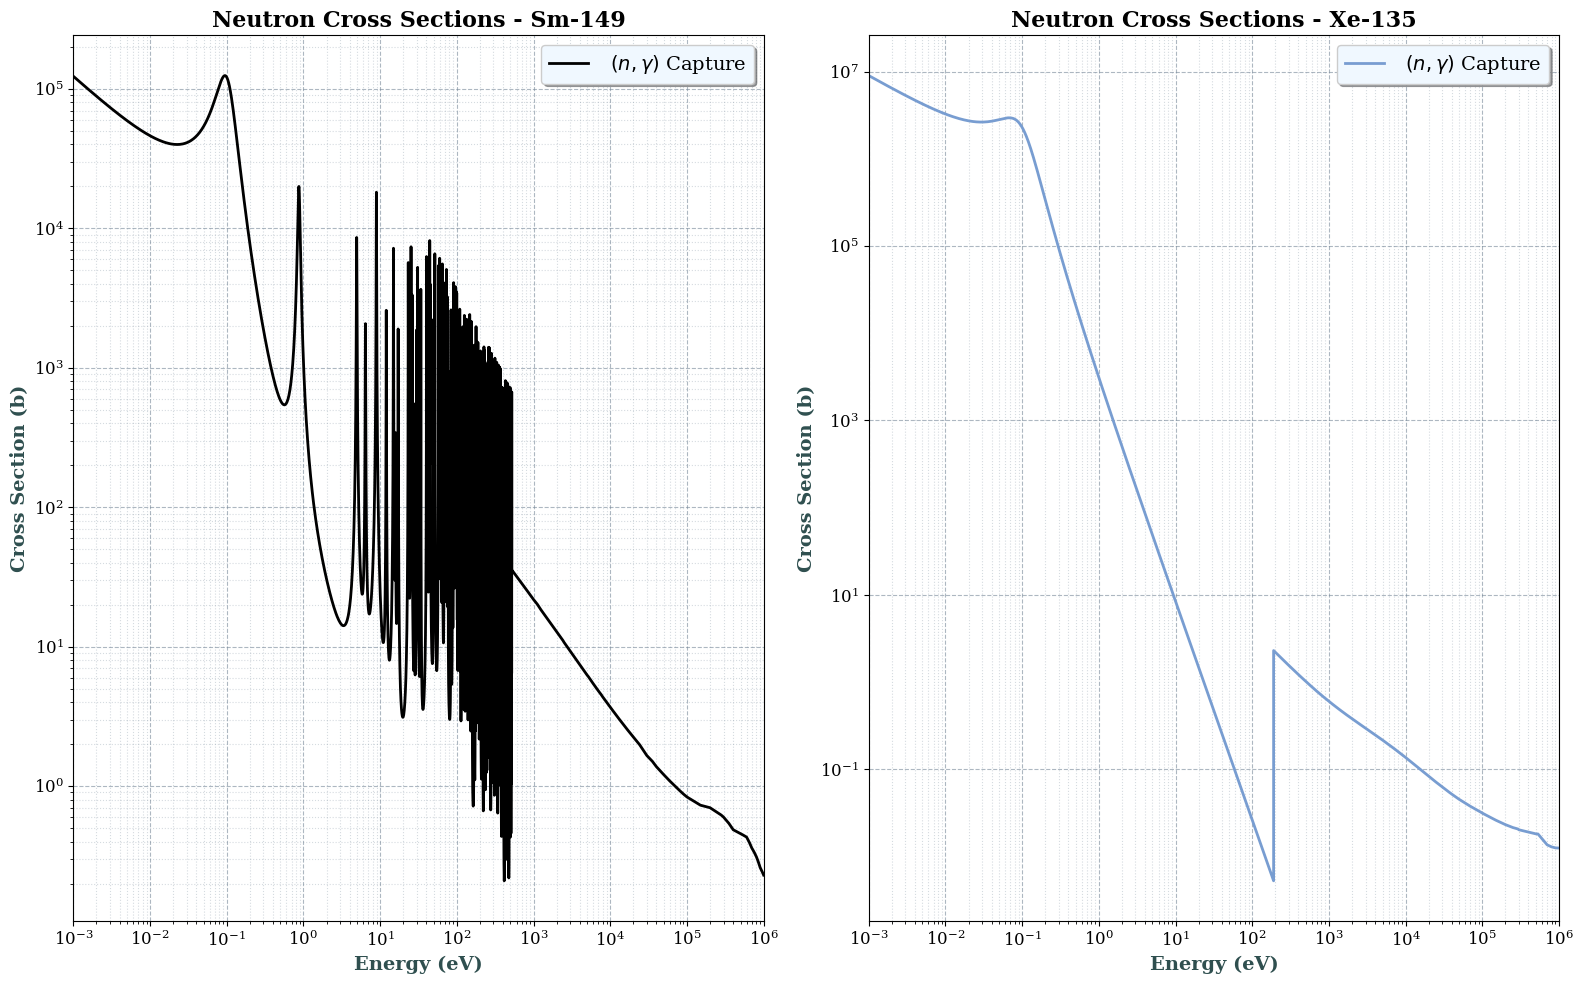

In [11]:
import os
import openmc.data
import matplotlib.pyplot as plt

# --- 1. SETUP DATI NUCLEARI ---
path_pc = "/home/bossi_ricky/openmc_data/mcnp_endfb71"
path_arco = "/raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71"

base_path = path_arco if os.path.exists(path_arco) else path_pc
openmc.config['cross_sections'] = f"{base_path}/cross_sections.xml"

# Caricamento libreria neutronica
lib = openmc.data.DataLibrary.from_xml(openmc.config['cross_sections'])
path_sm149 = lib.get_by_material('Sm149', data_type='neutron')['path']
path_xe135 = lib.get_by_material('Xe135', data_type='neutron')['path']

sm149 = openmc.data.IncidentNeutron.from_hdf5(path_sm149)
xe135 = openmc.data.IncidentNeutron.from_hdf5(path_xe135)

# --- 2. PLOT ---

mts_to_plot = {
    102: "$(n, \gamma)$ Capture"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
linestyles = ['-']

for ax, iso_data, title, base_color in zip(axes, [sm149, xe135], ['Sm-149', 'Xe-135'], ['#000000', '#789DD1']):
    
    # Identificazione della prima temperatura tabulata (es. 294K)
    temp = list(iso_data.energy.keys())[0]
    energies_ev = iso_data.energy[temp]
    
    # Maschera per il range energetico: 1 meV (1e-3 eV) a 1 MeV (1e6 eV)
    mask = (energies_ev >= 1e-3) & (energies_ev <= 1e6)
    e_plot = energies_ev[mask]
    
    for (mt, label), ls in zip(mts_to_plot.items(), linestyles):
        if mt in iso_data.reactions:
            rx = iso_data.reactions[mt]
            xs_full = rx.xs[temp](energies_ev)
            xs_plot = xs_full[mask]
            
            ax.loglog(e_plot, xs_plot, label=f' {label}', 
                      color=base_color, linestyle=ls, linewidth=2)
            
    # Formattazione
    ax.set_title(f"Neutron Cross Sections - {title}", fontsize=16, fontweight='bold')
    ax.set_xlabel('Energy (eV)', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel("Cross Section (b)", fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # Limiti rigorosi
    ax.set_xlim(1e-3, 1e6)
    
    # Formattazione Griglia e Legenda
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')

plt.tight_layout()
plt.savefig('neutron_cross_sections_sm149_xe135.png', dpi=300, bbox_inches='tight')
plt.show()